In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('place.csv')

In [6]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


<Axes: xlabel='placement_exam_marks', ylabel='Count'>

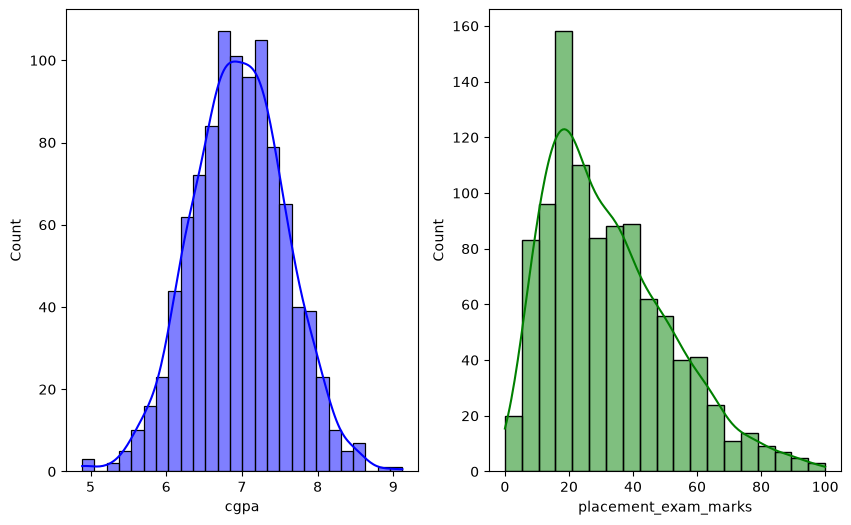

In [7]:
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
sns.histplot(df['cgpa'], kde=True, color='blue')

plt.subplot(1,2,2)
sns.histplot(df['placement_exam_marks'], kde=True, color='green')


In [8]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: xlabel='placement_exam_marks'>

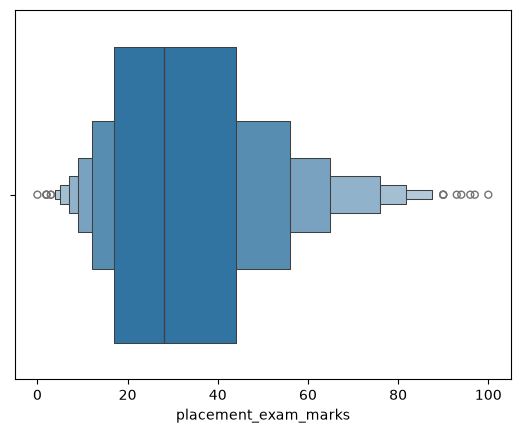

In [11]:
sns.boxenplot(x='placement_exam_marks', data=df)

In [12]:
per25 = df['placement_exam_marks'].quantile(0.25)
per75 = df['placement_exam_marks'].quantile(0.75)

In [17]:
print(per25)

17.0


In [22]:
print(per75)

44.0


In [13]:
iqr = per75 - per25

In [15]:
print(iqr)

27.0


In [18]:
upper_bound = per75 + (1.5 * iqr)
lower_bound = per25 - (1.5 * iqr)

In [19]:
print("Upper_bound", upper_bound)   
print("Lower_bound", lower_bound)

Upper_bound 84.5
Lower_bound -23.5


In [20]:
df[df['placement_exam_marks'] > upper_bound]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [23]:
df[df['placement_exam_marks'] < lower_bound]

,cgpa,placement_exam_marks,placed


## Trimming

In [24]:
new_df = df[df['placement_exam_marks'] < upper_bound]

In [26]:
new_df.shape

(985, 3)

<Axes: xlabel='placement_exam_marks'>

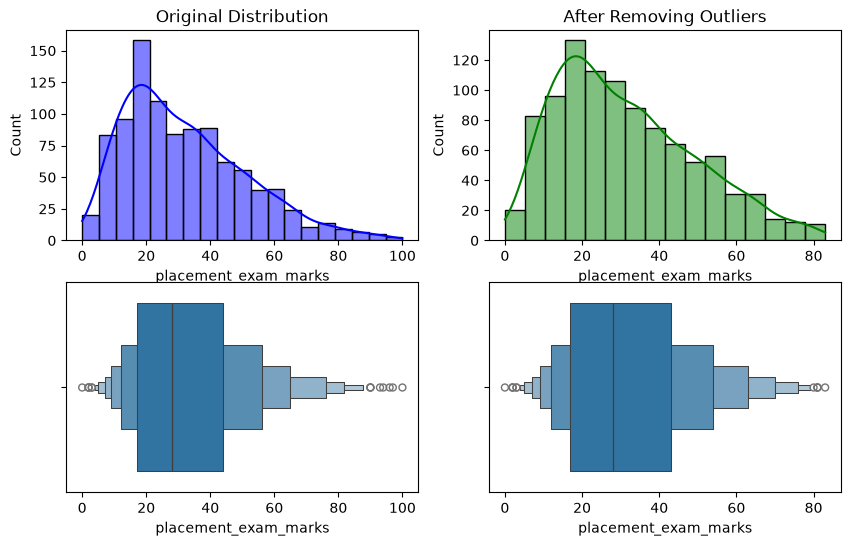

In [33]:
plt.figure(figsize=(10,6))
plt.subplot(2,2,1)
sns.histplot(df['placement_exam_marks'], kde=True, color='blue')
plt.title('Original Distribution')

plt.subplot(2,2,2)
sns.histplot(new_df['placement_exam_marks'], kde=True, color='green')
plt.title('After Removing Outliers')

plt.subplot(2,2,3)
sns.boxenplot(x='placement_exam_marks', data=df)

plt.subplot(2,2,4)
sns.boxenplot(x='placement_exam_marks', data=new_df)

## Capping

In [34]:
new_df_cap = df.copy()

new_df_cap['placement_exam_marks'] = np.where(new_df_cap['placement_exam_marks'] > upper_bound, upper_bound, 
             np.where(new_df_cap['placement_exam_marks'] < lower_bound, lower_bound, new_df_cap['placement_exam_marks']))

In [36]:
new_df_cap.shape

(1000, 3)